In [1]:
import os
import pandas as pd
import json

pd.set_option('display.max_columns', 20)      # 最多显示100行
pd.set_option('display.max_rows', 250)      # 最多显示100行

pd.set_option('display.width', 2000)      # 最多显示100行
def json_files_to_dataframe(folder_path):
    """读取文件夹中所有 JSON 文件并合并为 DataFrame"""
    file_lst = [x for x in os.listdir(folder_path) if x.endswith('.json')]
    
    if not file_lst:
        print("❌ 没有找到 JSON 文件")
        return pd.DataFrame()
    
    data_list = []
    
    for file_name in file_lst:
        file_path = os.path.join(folder_path, file_name)
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            if isinstance(data, dict):
                # data['source_file'] = file_name
                data_list.append(data)
            elif isinstance(data, list):
                # 如果是列表，为每个元素添加文件名
                # for item in data:
                    # if isinstance(item, dict):
                        # item['source_file'] = file_name
                data_list.extend(data)
                
        except Exception as e:
            print(f"❌ 读取文件失败 {file_name}: {e}")
            continue
    
    if not data_list:
        print("❌ 没有成功读取任何数据")
        return pd.DataFrame()
    
    # 创建 DataFrame
    df = pd.DataFrame(data_list)
    df['time_recently'] = df['time_recently'].str.replace('.500000', '')
    df['time_recently'] = pd.to_datetime(df['time_recently']).dt.strftime('%Y-%m-%d %H:%M:%S')
    print(f"✅ 成功读取 {len(data_list)} 条记录，来自 {len(file_lst)} 个文件")
    return df


In [2]:
def calc_trade_lst(df):
    trade = []
    for n, time in enumerate(df.index[:-5]):
        if n>=9:
            if n==9:
                if df.loc[time, 'now_pos'] != 0:
                    trade_price = df.loc[time, 'tick6t60avg']
                    open_time = time

            now_pos = df.loc[time, 'now_pos']
            last_pos = df.loc[df.index[n-1], 'now_pos']

            trade_price = df.loc[df.index[n+1], 'tick6t60avg']
            if now_pos != last_pos:
                if now_pos == 1:
                    if last_pos == 0:
                        open_price = trade_price
                        open_time = time
                    if last_pos == -1:
                        trade.append([-1, open_time, time, open_price, trade_price])
                        open_price = trade_price
                        open_time = time

                if now_pos == -1:
                    if last_pos == 0:
                        open_price = trade_price
                        open_time = time
                    if last_pos == 1:
                        trade.append([1, open_time, time, open_price, trade_price])    
                        open_price = trade_price
                        open_time = time               

                if now_pos == 0:
                    if last_pos == -1:
                        trade.append([-1, open_time, time, open_price, trade_price])
                    if last_pos == 1:
                        trade.append([1, open_time, time, open_price, trade_price])

    return trade

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

def plot_trading_chart_simple(df, trade_df, symbol, date):
    """简化版本 - 所有标签右移一根bar"""
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.7, 0.3]
    )
    
    # 蜡烛图 - 红色涨绿色跌
    fig.add_trace(go.Candlestick(
        x=df.index, 
        open=df['open'], 
        high=df['high'], 
        low=df['low'], 
        close=df['close'], 
        name='价格',
        increasing_line_color='red',    # 涨为红色
        decreasing_line_color='green',  # 跌为绿色
        increasing_fillcolor='red',     # 涨的填充色
        decreasing_fillcolor='green'    # 跌的填充色
    ), row=1, col=1)
    
    # 获取df的时间索引列表
    time_indices = list(df.index)
    
    # 交易标记
    if not trade_df.empty:
        for _, row in trade_df.iterrows():
            time_o_str = str(row['time_o'])
            time_c_str = str(row['time_c'])
            
            # 找到开仓时间在df中的位置
            if time_o_str in time_indices:
                idx = time_indices.index(time_o_str)
                # 右移一根bar
                if idx < len(time_indices) - 1:
                    time_o_shifted = time_indices[idx + 1]
                else:
                    time_o_shifted = time_o_str
            else:
                time_o_shifted = time_o_str
            
            # 找到平仓时间在df中的位置
            if time_c_str in time_indices:
                idx = time_indices.index(time_c_str)
                # 右移一根bar
                if idx < len(time_indices) - 1:
                    time_c_shifted = time_indices[idx + 1]
                else:
                    time_c_shifted = time_c_str
            else:
                time_c_shifted = time_c_str
            
            if row['flag'] == 1:  # 做多
                y_pos = df.loc[time_o_str, 'low'] - 5 if time_o_str in df.index else row['price_o'] - 5
                fig.add_annotation(x=time_o_shifted, y=y_pos, text="▲", 
                                 font=dict(size=20, color="green"), showarrow=False)
            elif row['flag'] == -1:  # 做空
                y_pos = df.loc[time_o_str, 'high'] + 5 if time_o_str in df.index else row['price_o'] + 5
                fig.add_annotation(x=time_o_shifted, y=y_pos, text="▼", 
                                 font=dict(size=20, color="red"), showarrow=False)
            
            # 平仓标记
            fig.add_annotation(x=time_c_shifted, y=row['price_c'], text="✕", 
                             font=dict(size=18, color="black", family="Arial Black"), showarrow=False)
    
    
    if 'volume' in df.columns:
        fig.add_trace(go.Scatter(
            x=df.index, y=df['volume'],
            mode='lines', name='volume',
            line=dict(color='blue', width=1)
        ), row=2, col=1)
    
    fig.update_layout(
        title=f'{symbol} - {date}',
        height=700,
        xaxis_rangeslider_visible=False,
        showlegend=False
    )
    fig.update_xaxes(type='category')

    return fig

In [4]:
from function_res import *
symbol = 'IF'
date = '20260518'

In [5]:
folder_path = f'/mnt/Data/writable/liaoyuyang/history_realtime_data/{date}'
df = json_files_to_dataframe(folder_path).set_index('time_recently').sort_index()
df.index = df.index.map(lambda x: x[:-1] + '0')

main_data = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0).set_index('ts')

# 修改索引中的13:00:00为11:30:00
df.index = df.index.map(lambda x: x.replace("13:00:00", "11:30:00"))
df = df[~df.index.duplicated(keep='first')]
# 之后merge
df = df.join(main_data[['tick6t60avg', 'open', 'high', 'low', 'close', 'volume']])

trade_df = pd.DataFrame(calc_trade_lst(df), columns=['flag', 'time_o', 'time_c', 'price_o', 'price_c'])
trade_df['profit'] = trade_df.flag * (trade_df['price_c'] - trade_df['price_o'])

✅ 成功读取 239 条记录，来自 239 个文件


<Axes: xlabel='time_recently'>

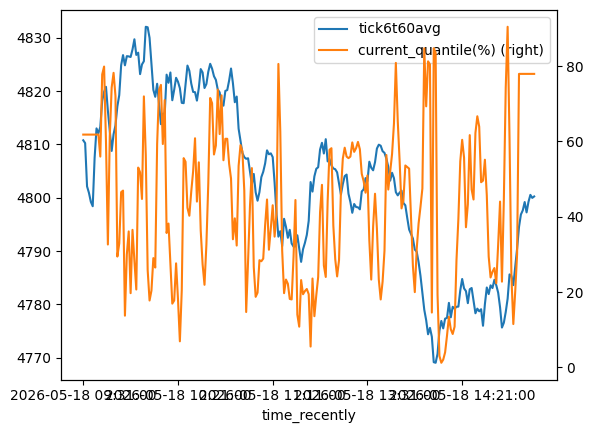

In [6]:
df[['tick6t60avg', 'current_quantile(%)']].plot(secondary_y='current_quantile(%)')

In [7]:
print(trade_df.profit.sum())
trade_df

-4.304332000001523


,flag,time_o,time_c,price_o,price_c,profit
0,-1,2026-05-18 09:53:00,2026-05-18 10:03:00,4826.528972,4832.038095,-5.509123
1,-1,2026-05-18 10:06:00,2026-05-18 10:11:00,4825.118868,4813.781308,11.337560
2,-1,2026-05-18 10:18:00,2026-05-18 10:38:00,4820.230189,4824.190196,-3.960007
3,-1,2026-05-18 10:57:00,2026-05-18 11:14:00,4807.390099,4793.714563,13.675536
4,1,2026-05-18 11:14:00,2026-05-18 11:17:00,4793.714563,4794.540952,0.826389
5,-1,2026-05-18 11:17:00,2026-05-18 13:34:00,4794.540952,4806.646465,-12.105513
6,-1,2026-05-18 13:38:00,2026-05-18 13:46:00,4808.716129,4800.432558,8.283571
7,1,2026-05-18 13:46:00,2026-05-18 13:55:00,4800.432558,4790.270476,-10.162082
8,-1,2026-05-18 13:56:00,2026-05-18 14:01:00,4789.868750,4777.033645,12.835105
9,1,2026-05-18 14:01:00,2026-05-18 14:05:00,4777.033645,4769.157407,-7.876238


In [8]:
plot_trading_chart_simple(df, trade_df, symbol, date)

In [9]:
df = main_data.groupby('trade_date', group_keys=False).apply(lambda x :x.iloc[10:-10],include_groups=False)

In [10]:
df

,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,open_interest,spread,bar_count,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_3,rtn_5,rtn_10
ts,,,,,,,,,,,,,,,,,,,,
2018-01-02 09:41:00,IF1803,4075.0,4076.0,4075.0,4076.0,4075.513636,4075.259461,8.0,8559060.0,10325.0,1.522727,44,4075.18,4075.433333,4075.133333,4075.489474,-0.001156,-0.001738,-0.001216,0.001537
2018-01-02 09:42:00,IF1803,4076.0,4076.0,4075.0,4075.0,4075.570370,4075.252696,14.0,13448400.0,10323.0,0.962963,27,4075.71,4076.000000,4076.000000,4075.553846,-0.000582,-0.000073,0.000274,0.002426
2018-01-02 09:43:00,IF1803,4075.0,4075.0,4067.2,4067.2,4070.969863,4070.378266,19.0,19541220.0,10314.0,2.112329,73,4073.98,4073.050000,4074.666667,4070.841791,-0.000000,0.000523,0.001732,0.003161
2018-01-02 09:44:00,IF1803,4067.2,4069.6,4066.6,4066.6,4068.297500,4069.168311,9.0,10983960.0,10316.0,2.547500,80,4068.40,4067.835294,4069.230769,4068.471429,0.000510,0.000858,0.002569,0.002881
2018-01-02 09:45:00,IF1803,4066.6,4072.0,4066.6,4069.8,4068.358442,4070.042670,4.0,4884240.0,10314.0,2.472727,77,4066.86,4067.233333,4066.963636,4068.469565,0.000014,0.001221,0.002762,0.002837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-18 14:46:00,IF2606,4782.4,4787.0,4782.4,4785.8,4785.447863,4785.448183,403.0,578529360.0,147844.0,0.442735,6903,4784.20,4784.345455,4784.880000,4785.613333,-0.000359,NaN,0.002409,0.003178
2026-05-18 14:47:00,IF2606,4785.8,4786.4,4784.2,4784.2,4785.308772,4785.359781,187.0,268450740.0,147898.0,0.471930,6555,4785.28,4785.200000,4784.905263,4785.317647,0.000731,NaN,0.002933,0.003419
2026-05-18 14:48:00,IF2606,4784.2,4785.0,4781.4,4783.0,4783.679646,4783.636904,225.0,322887720.0,147939.0,0.460177,6441,4784.64,4784.500000,4784.562500,4783.601961,0.000701,NaN,0.002525,0.002743


In [11]:
df.rtn_1.sort_values()

ts
2024-10-08 10:35:00   -0.015910
2019-05-10 11:29:00   -0.011696
2024-09-27 13:19:00   -0.011013
2024-10-08 10:13:00   -0.010583
2024-10-08 13:04:00   -0.008817
                         ...   
2019-10-10 11:23:00         NaN
2025-09-16 11:19:00         NaN
2025-09-16 11:20:00         NaN
2025-10-13 11:29:00         NaN
2025-10-13 11:30:00         NaN
Name: rtn_1, Length: 445489, dtype: float64